# Import Library

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import random
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("Library Loaded!")

Library Loaded!


In [ ]:
DATA_PATH = "/content/drive/MyDrive/ABSA_Review_Aspect_Pairs_Raw_New.xlsx"

df = pd.read_excel(DATA_PATH)

print(df.shape)

df.head()

(8015, 15)


,review_id,review,review_clean,rating,date,thumbs_up,aspect,aspect_category,matched_keywords,confidence_score,is_gamification_final,aspect_verified,aspect_changed,sentiment,notes
0,0,saya mendapatkan 380 koin ya bos,saya mendapatkan 380 koin ya bos,5,2025-12-30 23:18:54,0,points,Components,koin,2,Yes,points,No,Positive,NaN
1,2,Alhamdulillah dapat koin 50 semoga lebih besar...,alhamdulillah dapat koin 50 semoga lebih besar...,5,2025-12-30 18:00:08,0,points,Components,koin,2,Yes,points,No,Positive,NaN
2,2,Alhamdulillah dapat koin 50 semoga lebih besar...,alhamdulillah dapat koin 50 semoga lebih besar...,5,2025-12-30 18:00:08,0,resource_acquisition,Mechanics,dapat koin,3,Yes,resource_acquisition,No,Positive,NaN
3,3,cara mudah belanja dan mudah untuk mendapatkan...,cara mudah belanja dan mudah untuk mendapatkan...,5,2025-12-30 16:56:57,0,points,Components,koin,2,Yes,points,No,Positive,NaN
4,5,"saya masih berlangganan shoopie VIP,tp entah k...","saya masih berlangganan shoopie vip,tp entah k...",4,2025-12-30 13:52:04,0,emotions,Dynamics,kesal,2,Yes,emotions,No,Negative,NaN


In [ ]:
df = df.dropna(subset=["sentiment"])
df = df.reset_index(drop=True)

In [ ]:
df.isnull().sum()

,0
review_id,0
review,0
review_clean,0
rating,0
date,0
thumbs_up,0
aspect,0
aspect_category,0
matched_keywords,0
confidence_score,0


In [ ]:
df = df.copy()

df["is_gamification_final"] = (
    df["is_gamification_final"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df = df.reset_index(drop=True)

print(df.shape)

df.head()

(7961, 15)


,review_id,review,review_clean,rating,date,thumbs_up,aspect,aspect_category,matched_keywords,confidence_score,is_gamification_final,aspect_verified,aspect_changed,sentiment,notes
0,0,saya mendapatkan 380 koin ya bos,saya mendapatkan 380 koin ya bos,5,2025-12-30 23:18:54,0,points,Components,koin,2,yes,points,No,Positive,NaN
1,2,Alhamdulillah dapat koin 50 semoga lebih besar...,alhamdulillah dapat koin 50 semoga lebih besar...,5,2025-12-30 18:00:08,0,points,Components,koin,2,yes,points,No,Positive,NaN
2,2,Alhamdulillah dapat koin 50 semoga lebih besar...,alhamdulillah dapat koin 50 semoga lebih besar...,5,2025-12-30 18:00:08,0,resource_acquisition,Mechanics,dapat koin,3,yes,resource_acquisition,No,Positive,NaN
3,3,cara mudah belanja dan mudah untuk mendapatkan...,cara mudah belanja dan mudah untuk mendapatkan...,5,2025-12-30 16:56:57,0,points,Components,koin,2,yes,points,No,Positive,NaN
4,5,"saya masih berlangganan shoopie VIP,tp entah k...","saya masih berlangganan shoopie vip,tp entah k...",4,2025-12-30 13:52:04,0,emotions,Dynamics,kesal,2,yes,emotions,No,Negative,NaN


In [ ]:
dataset = df[
    [
        "review_clean",
        "aspect_verified",
        "sentiment"
    ]
].copy()

dataset.columns = [
    "text",
    "aspect",
    "sentiment"
]

dataset.head()

,text,aspect,sentiment
0,saya mendapatkan 380 koin ya bos,points,Positive
1,alhamdulillah dapat koin 50 semoga lebih besar...,points,Positive
2,alhamdulillah dapat koin 50 semoga lebih besar...,resource_acquisition,Positive
3,cara mudah belanja dan mudah untuk mendapatkan...,points,Positive
4,"saya masih berlangganan shoopie vip,tp entah k...",emotions,Negative


In [ ]:
dataset["aspect"].value_counts()

,count
aspect,
points,4658
narrative,633
rewards,617
emotions,555
resource_acquisition,542
challenges,252
win_states,204
quests,84
in_game_transactions,76


In [ ]:
dataset["sentiment"].value_counts()

,count
sentiment,
Negative,4708
Positive,2955
Neutral,298


In [ ]:
aspect_encoder = LabelEncoder()

dataset["aspect_label"] = aspect_encoder.fit_transform(
    dataset["aspect"]
)

dataset.head()

,text,aspect,sentiment,aspect_label
0,saya mendapatkan 380 koin ya bos,points,Positive,18
1,alhamdulillah dapat koin 50 semoga lebih besar...,points,Positive,18
2,alhamdulillah dapat koin 50 semoga lebih besar...,resource_acquisition,Positive,22
3,cara mudah belanja dan mudah untuk mendapatkan...,points,Positive,18
4,"saya masih berlangganan shoopie vip,tp entah k...",emotions,Negative,11


In [ ]:
sentiment_encoder = LabelEncoder()

dataset["sentiment_label"] = sentiment_encoder.fit_transform(
    dataset["sentiment"]
)

dataset.head()

,text,aspect,sentiment,aspect_label,sentiment_label
0,saya mendapatkan 380 koin ya bos,points,Positive,18,2
1,alhamdulillah dapat koin 50 semoga lebih besar...,points,Positive,18,2
2,alhamdulillah dapat koin 50 semoga lebih besar...,resource_acquisition,Positive,22,2
3,cara mudah belanja dan mudah untuk mendapatkan...,points,Positive,18,2
4,"saya masih berlangganan shoopie vip,tp entah k...",emotions,Negative,11,0


In [ ]:
dataset["stratify_label"] = (
    dataset["aspect"].astype(str)
    + "_"
    + dataset["sentiment"].astype(str)
)

In [ ]:
aspect_mapping = pd.DataFrame({

    "Aspect": aspect_encoder.classes_,

    "Label": range(len(aspect_encoder.classes_))

})

sentiment_mapping = pd.DataFrame({

    "Sentiment": sentiment_encoder.classes_,

    "Label": range(len(sentiment_encoder.classes_))

})

print(aspect_mapping)

print()

print(sentiment_mapping)

                  Aspect  Label
0           achievements      0
1                 badges      1
2            boss_fights      2
3             challenges      3
4                 chance      4
5            collections      5
6                 combat      6
7            competition      7
8            constraints      8
9      content_unlocking      9
10           cooperation     10
11              emotions     11
12              feedback     12
13               gifting     13
14  in_game_transactions     14
15          leaderboards     15
16                levels     16
17             narrative     17
18                points     18
19           progression     19
20                quests     20
21         relationships     21
22  resource_acquisition     22
23               rewards     23
24          social_graph     24
25                 teams     25
26                 turns     26
27            win_states     27

  Sentiment  Label
0  Negative      0
1   Neutral      1
2  Positive   

# Split the Data

In [ ]:
train_df, temp_df = train_test_split(

    dataset,

    test_size=0.20,

    random_state=SEED,

    stratify=dataset["sentiment_label"]

)

In [ ]:
valid_df, test_df = train_test_split(

    temp_df,

    test_size=0.50,

    random_state=SEED,

    stratify=temp_df["sentiment_label"]

)

In [ ]:
print("="*50)

print("Train :", train_df.shape)

print("Validation :", valid_df.shape)

print("Test :", test_df.shape)

print("="*50)

Train : (6368, 6)
Validation : (796, 6)
Test : (797, 6)


In [ ]:
train_df["sentiment"].value_counts()
valid_df["sentiment"].value_counts()
test_df["sentiment"].value_counts()

,count
sentiment,
Negative,471
Positive,296
Neutral,30


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/ABSA_Training_New"

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

In [ ]:
train_df.to_csv(

    SAVE_DIR+"/train.csv",

    index=False

)

valid_df.to_csv(

    SAVE_DIR+"/validation.csv",

    index=False

)

test_df.to_csv(

    SAVE_DIR+"/test.csv",

    index=False

)

aspect_mapping.to_csv(

    SAVE_DIR+"/aspect_mapping.csv",

    index=False

)

sentiment_mapping.to_csv(

    SAVE_DIR+"/sentiment_mapping.csv",

    index=False

)

print("Saved Successfully!")

Saved Successfully!


In [ ]:
train_df.head()

,text,aspect,sentiment,aspect_label,sentiment_label,stratify_label
6501,sungguh disayangkan fitur kirim koin di hilang...,chance,Negative,4,0,chance_Negative
4117,semoga lebih banyak lagi bagi koin nya,points,Positive,18,2,points_Positive
4470,"koin nonton live tdk masuk ke tabungan koin ,m...",points,Negative,18,0,points_Negative
834,bagus beragam jenis voucher game untuk mengump...,rewards,Positive,23,2,rewards_Positive
4896,"aplikasi oon, udah smpe di titik tujuan cs tid...",points,Negative,18,0,points_Negative


In [ ]:
print("="*50)
print("TRAIN")
print(train_df.head())

print("="*50)
print("VALIDATION")
print(valid_df.head())

print("="*50)
print("TEST")
print(test_df.head())

TRAIN
                                                   text   aspect sentiment  \
6501  sungguh disayangkan fitur kirim koin di hilang...   chance  Negative   
4117             semoga lebih banyak lagi bagi koin nya   points  Positive   
4470  koin nonton live tdk masuk ke tabungan koin ,m...   points  Negative   
834   bagus beragam jenis voucher game untuk mengump...  rewards  Positive   
4896  aplikasi oon, udah smpe di titik tujuan cs tid...   points  Negative   

      aspect_label  sentiment_label    stratify_label  
6501             4                0   chance_Negative  
4117            18                2   points_Positive  
4470            18                0   points_Negative  
834             23                2  rewards_Positive  
4896            18                0   points_Negative  
VALIDATION
                                                   text                aspect  \
6900                                       koin g masuk                points   
6753  ya allah s

In [ ]:
print(train_df.columns)

print(train_df.shape)

train_df.isna().sum()

Index(['text', 'aspect', 'sentiment', 'aspect_label', 'sentiment_label',
       'stratify_label'],
      dtype='object')
(6368, 6)


,0
text,0
aspect,0
sentiment,0
aspect_label,0
sentiment_label,0
stratify_label,0


In [ ]:
aspect_distribution = (
    dataset["aspect"]
    .value_counts()
    .reset_index()
)

aspect_distribution.columns = [
    "Aspect",
    "Frequency"
]

aspect_distribution["Percentage"] = (
    aspect_distribution["Frequency"]
    / aspect_distribution["Frequency"].sum()
    *100
).round(2)

aspect_distribution

,Aspect,Frequency,Percentage
0,points,4658,58.51
1,narrative,633,7.95
2,rewards,617,7.75
3,emotions,555,6.97
4,resource_acquisition,542,6.81
5,challenges,252,3.17
6,win_states,204,2.56
7,quests,84,1.06
8,in_game_transactions,76,0.95
9,turns,66,0.83


In [ ]:
aspect_distribution.to_excel(
    "/content/drive/MyDrive/Aspect_Distribution.xlsx",
    index=False
)

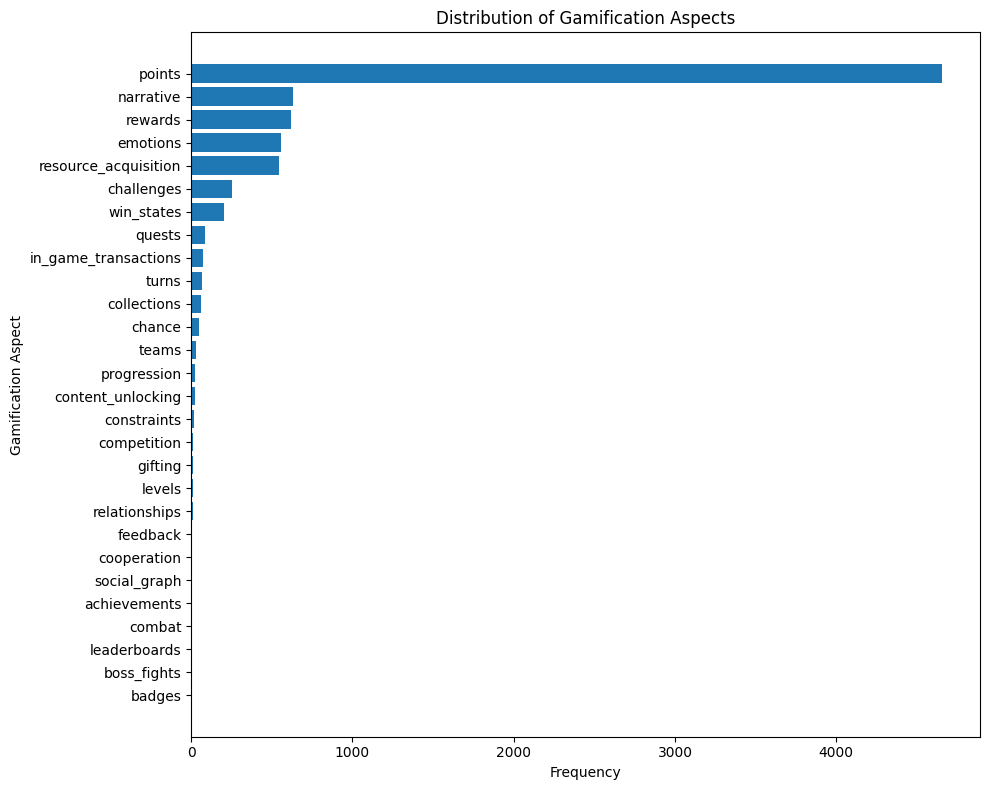

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

aspect_distribution = aspect_distribution.sort_values(
    "Frequency"
)

plt.barh(
    aspect_distribution["Aspect"],
    aspect_distribution["Frequency"]
)

plt.xlabel("Frequency")
plt.ylabel("Gamification Aspect")
plt.title("Distribution of Gamification Aspects")

plt.tight_layout()

plt.show()

In [ ]:
plt.savefig(
    "/content/drive/MyDrive/Figure_4_4_Distribution_of_Gamification_Aspects.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

,Sentiment,Frequency,Percentage (%)
0,Negative,4708,59.14
1,Positive,2955,37.12
2,Neutral,298,3.74


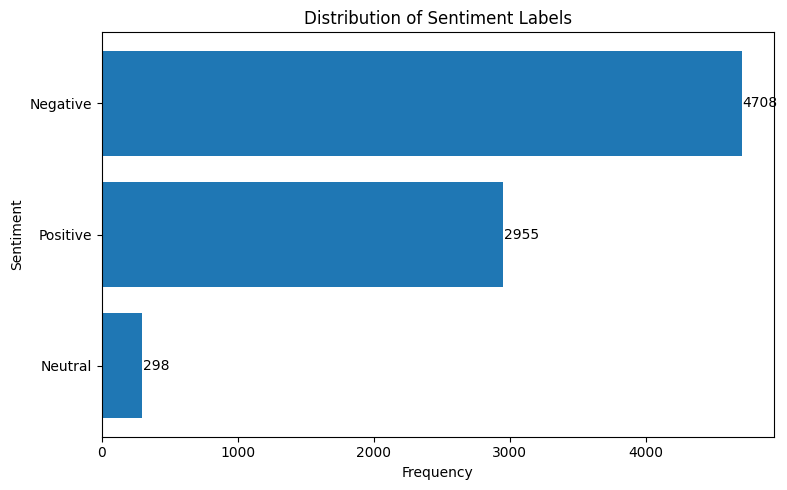

✅ Table 4.9 dan Figure 4.5 berhasil disimpan!


In [ ]:
# =====================================================
# SENTIMENT DISTRIBUTION
# =====================================================

import matplotlib.pyplot as plt

# Membuat tabel distribusi
sentiment_distribution = (
    dataset["sentiment"]
    .value_counts()
    .reset_index()
)

sentiment_distribution.columns = [
    "Sentiment",
    "Frequency"
]

# Menambahkan persentase
sentiment_distribution["Percentage (%)"] = (
    sentiment_distribution["Frequency"]
    / sentiment_distribution["Frequency"].sum()
    * 100
).round(2)

# Tampilkan tabel
display(sentiment_distribution)

# Simpan ke Excel
SAVE_DIR = "/content/drive/MyDrive/ABSA_Result"

import os
os.makedirs(SAVE_DIR, exist_ok=True)

sentiment_distribution.to_excel(
    f"{SAVE_DIR}/Table_4_9_Sentiment_Distribution.xlsx",
    index=False
)

# =====================================================
# HORIZONTAL BAR CHART
# =====================================================

plot_df = sentiment_distribution.sort_values(
    "Frequency",
    ascending=True
)

plt.figure(figsize=(8,5))

bars = plt.barh(
    plot_df["Sentiment"],
    plot_df["Frequency"]
)

# Tambahkan angka di ujung bar
for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 5,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center",
        fontsize=10
    )

plt.xlabel("Frequency")
plt.ylabel("Sentiment")
plt.title("Distribution of Sentiment Labels")

plt.tight_layout()

plt.savefig(
    f"{SAVE_DIR}/Figure_4_5_Sentiment_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Table 4.9 dan Figure 4.5 berhasil disimpan!")

In [ ]:
# =====================================================
# ASPECT × SENTIMENT DISTRIBUTION
# =====================================================

aspect_sentiment = pd.crosstab(
    dataset["aspect"],
    dataset["sentiment"]
)

# Total
aspect_sentiment["Total"] = aspect_sentiment.sum(axis=1)

# Dominant sentiment
aspect_sentiment["Dominant Sentiment"] = (
    aspect_sentiment.iloc[:,:-1]
    .idxmax(axis=1)
)

aspect_sentiment = aspect_sentiment.sort_values(
    "Total",
    ascending=False
)

display(aspect_sentiment)

aspect_sentiment.to_excel(
    "/content/drive/MyDrive/ABSA_Result/Table_Aspect_Sentiment.xlsx"
)

sentiment,Negative,Neutral,Positive,Total,Dominant Sentiment
aspect,,,,,
points,2601,184,1873,4658,Negative
narrative,541,30,62,633,Negative
rewards,299,30,288,617,Negative
emotions,322,7,226,555,Negative
resource_acquisition,185,9,348,542,Positive
challenges,232,4,16,252,Negative
win_states,172,3,29,204,Negative
quests,61,7,16,84,Negative
in_game_transactions,39,9,28,76,Negative


In [ ]:
aspect_percentage = (
    pd.crosstab(
        dataset["aspect"],
        dataset["sentiment"],
        normalize="index"
    )*100
).round(2)

display(aspect_percentage)

aspect_percentage.to_excel(
    "/content/drive/MyDrive/ABSA_Result/Table_Aspect_Sentiment_Percentage.xlsx"
)

sentiment,Negative,Neutral,Positive
aspect,,,
achievements,33.33,33.33,33.33
badges,100.00,0.00,0.00
boss_fights,100.00,0.00,0.00
challenges,92.06,1.59,6.35
chance,78.00,16.00,6.00
collections,68.75,0.00,31.25
combat,100.00,0.00,0.00
competition,41.67,0.00,58.33
constraints,87.50,6.25,6.25
